# Tek ve Çok Değişkenli Aykırı Değer
Bir önceki konuda kısaca değindiğimiz bu ayrımı şimdi derinlemesine ele 
alıyoruz — çünkü tespit yöntemi, hangi türle uğraştığımıza göre değişir.

## Tek Değişkenli (Univariate) Aykırı Değer
**Tek bir değişkende**, diğer değerlerden çok uzak olan bir gözlem. 
Tespiti nispeten kolay — o değişkenin dağılımına bakmak yeterli 
(histogram, box plot, Z-Score).

*Örnek:* Bir müşterinin yaşı 150 görünüyor — bu, sadece "Yaş" 
değişkenine bakarak bile anlaşılabilir bir aykırılık.

## Çok Değişkenli (Multivariate) Aykırı Değer — Daha Sinsi
Bir gözlemin **her bir değişkeni tek başına normal** görünse de, 
**değişkenlerin kombinasyonu** anormal olabilir. Bu, tek tek 
değişkenlere bakarak **yakalanamaz** — değişkenler arasındaki ilişkiyi 
(Varyans-Kovaryans Matrisi mantığını) hesaba katman gerekir.

*Klasik Örnek:* Bir kişinin **Yaşı 8** (normal bir yaş) ve **Boyu 180cm** 
(normal bir boy) olsun. Tek tek bakınca ikisi de "normal" aralıkta. Ama 
**8 yaşında 180cm boyunda olmak** son derece anormal bir kombinasyon — 
bu, sadece iki değişkeni **birlikte** değerlendirince ortaya çıkan bir 
aykırılık.

## Nasıl Tespit Edilir?

**Tek değişkenli için:**
- Z-Score (|Z|>2 veya 3)
- IQR yöntemi (Q1-1.5×IQR'den küçük veya Q3+1.5×IQR'den büyük)
- Box plot (görsel)

**Çok değişkenli için:**
- **Mahalanobis Uzaklığı:** Bir gözlemin, değişkenler arasındaki 
  korelasyon yapısını da hesaba katarak, "merkeze" olan uzaklığını 
  ölçer — Konu 87'deki Varyans-Kovaryans Matrisi'ni kullanır
- **Scatter Plot (2 değişken için görsel):** İki değişkeni birlikte 
  çizip, "bulut"tan uzak noktalara bakmak
- **Isolation Forest, Local Outlier Factor (LOF):** ML tabanlı, ileri 
  seviye yöntemler (ML müfredatında daha detaylı göreceğiz)

## Mahalanobis Uzaklığı — Kısa Sezgi
Normal Öklid uzaklığı (düz çizgi mesafesi), değişkenler arasındaki 
ilişkiyi hesaba katmaz. Mahalanobis uzaklığı ise, "eğer değişkenler 
birbiriyle ilişkiliyse, bu ilişkiye göre normalleştirilmiş bir uzaklık" 
hesaplar — Yaş-Boy örneğimizdeki gibi "beklenen ilişkiden sapan" 
noktaları doğru şekilde "uzak" olarak işaretler.

## Python'da Kullanımı (Mahalanobis)
```python
from scipy.spatial.distance import mahalanobis
import numpy as np

kovaryans_matrisi = np.cov(df[['Yas','Boy']].values.T)
inv_kovaryans = np.linalg.inv(kovaryans_matrisi)
ortalama = df[['Yas','Boy']].mean().values

mesafe = mahalanobis(df.loc[0, ['Yas','Boy']].values, ortalama, inv_kovaryans)
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
n = 100

yas = np.random.uniform(1, 15, n)
boy = 50 + yas * 8 + np.random.normal(0, 5, n)

df = pd.DataFrame({'Yas': yas, 'Boy': boy})
df

,Yas,Boy
0,6.243562,100.383729
1,14.310000,162.984966
2,11.247915,140.442125
3,9.381219,115.111906
4,3.184261,74.375728
...,...,...
95,7.913138,109.226055
96,8.318260,116.160568
97,6.985574,107.590354
98,1.355868,62.230396


In [4]:
aykiri_satir = pd.DataFrame({'Yas':[8], 'Boy':[180]})
aykiri_satir

,Yas,Boy
0,8,180


In [5]:
df = pd.concat([df, aykiri_satir], ignore_index=True).copy()
df

,Yas,Boy
0,6.243562,100.383729
1,14.310000,162.984966
2,11.247915,140.442125
3,9.381219,115.111906
4,3.184261,74.375728
...,...,...
96,8.318260,116.160568
97,6.985574,107.590354
98,1.355868,62.230396
99,2.510480,74.219756


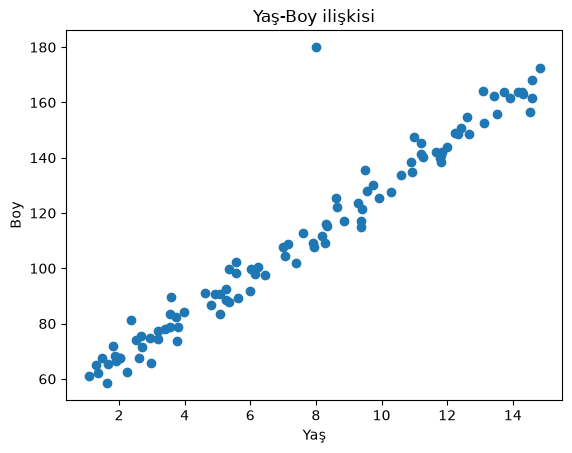

In [6]:
plt.scatter(df['Yas'], df['Boy'])
plt.xlabel('Yaş')
plt.ylabel('Boy')
plt.title('Yaş-Boy ilişkisi')
plt.show()

In [11]:
from scipy.spatial.distance import mahalanobis
kovaryans_matrisi = np.cov(df[['Yas', 'Boy']].values.T)
inv_kovaryans = np.linalg.inv(kovaryans_matrisi)
ortalama = df[['Yas', 'Boy']].mean().values

mesafeler = []
for i in range (len(df)):
    nokta = df.loc[i, ['Yas', 'Boy']].values
    mesafe = mahalanobis(nokta, ortalama, inv_kovaryans) # type: ignore
    mesafeler.append(mesafe)

df['Mahalanobis_Mesafe'] = mesafeler
print(df.sort_values('Mahalanobis_Mesafe', ascending=False).head(5))

           Yas         Boy  Mahalanobis_Mesafe
100   8.000000  180.000000            8.216780
34   14.518848  156.556932            2.034073
37    2.367410   81.255487            1.859701
69   14.816417  172.440451            1.827484
80   13.083448  163.996456            1.783790


### Sonuç
Değişkenler tek başına normal görünse de, birleştiklerinde ortaya anormal durumlar çıkabilir. Bizim örneğimizde yaşın 8 olması ve boyun 
180 olması ayrı ayrı normal olsa da, 8 yaşındaki birinin 180cm boyunda olması anormaldir. Bu tür çok değişkenli anormallikleri tespit etmek amacıyla kullanılan Mahalanobis Uzaklığı, sadece değişkenlerin ortalamasına değil, aynı zamanda değişkenler arasındaki ilişkiye (kovaryans yapısına) da bakarak her gözlemin merkeze olan uzaklığını hesaplar. Bu yöntemle 8 yaşında 180cm boyundaki gözlem, diğer gözlemlerden belirgin şekilde yüksek bir mesafeyle (8.22, ikinci en yüksek değerden ~4 kat fazla) aykırı değer olarak tespit edilmiştir. Bu sonuç, scatter plot'taki görsel bulgularla da tutarlıdır.